In [9]:
import pickle, joblib, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
class Profile:
    LEVE = "Perfil_Leve"
    MEDIO = "Perfil_Médio"
    PESADO = "Perfil_Pesado"

RESULTS_DIR = 'results'
PROFILES    = [Profile.LEVE, Profile.MEDIO]

profiles_data = {}
for profile in PROFILES:
    path = os.path.join(RESULTS_DIR, profile, 'results.pkl')
    with open(path, 'rb') as f:
        profiles_data[profile] = pickle.load(f)

curves_data = {}
for profile in PROFILES:
    path = os.path.join(RESULTS_DIR, profile, f'{profile}_curves.pkl')
    if os.path.exists(path):
        with open(path, 'rb') as f:
            curves_data[profile] = pickle.load(f)

colors = {
    'Perfil_Leve':  'steelblue',
    'Perfil_Médio': 'crimson',
    'Perfil_Pesado':'forestgreen',
}

line_styles = [
    {'linewidth': 2.5, 'alpha': 0.9},   # Perfil_Leve — linha grossa
    {'linewidth': 1.5, 'alpha': 0.6},   # Perfil_Médio — linha fina e transparente
    {'linewidth': 1.0, 'alpha': 0.4},   # Perfil_Pesado
]

In [11]:
rows = []
for profile, results in profiles_data.items():
    for model_name, res in results.items():
        rows.append({
            'Perfil':  profile,
            'Modelo':  model_name,
            'MAE':     res['mae_mean'],
            'MAE_std': res['mae_std'],
            'RMSE':    res['rmse_mean'],
            'RMSE_std':res['rmse_std'],
        })

df_cmp = pd.DataFrame(rows)
print("COMPARAÇÃO DE PERFIS MAE e RMSE")
print(df_cmp.to_string(index=False, float_format='%.4f'))

COMPARAÇÃO DE PERFIS MAE e RMSE
      Perfil    Modelo     MAE  MAE_std    RMSE  RMSE_std
 Perfil_Leve    Linear 37.5241   0.2943 57.4133    0.8076
 Perfil_Leve      Tree 36.3232   0.2406 59.5901    1.2444
 Perfil_Leve       SVM 36.7257   0.1978 59.4584    1.0699
 Perfil_Leve NeuralNet 36.0309   0.2125 56.9183    0.7215
Perfil_Médio    Linear 37.4969   0.2423 57.3225    0.6420
Perfil_Médio      Tree 36.3664   0.2719 59.1251    1.0318
Perfil_Médio       SVM 36.7167   0.2297 59.4238    0.9145
Perfil_Médio NeuralNet 35.6557   0.7148 56.7240    1.0049


In [12]:
if len(PROFILES) >= 2:
    p1 = df_cmp[df_cmp['Perfil'] == PROFILES[0]].set_index('Modelo')
    p2 = df_cmp[df_cmp['Perfil'] == PROFILES[1]].set_index('Modelo')

    diff = pd.DataFrame({
        'Δ MAE':  p2['MAE']  - p1['MAE'],
        'Δ RMSE': p2['RMSE'] - p1['RMSE'],
    })
    print("\nDiferença (Médio - Leve) de valores negativos = Médio é melhor:")
    print(diff.round(4).to_string())


Diferença (Médio - Leve) de valores negativos = Médio é melhor:
            Δ MAE  Δ RMSE
Modelo                   
Linear    -0.0272 -0.0907
Tree       0.0432 -0.4650
SVM       -0.0089 -0.0346
NeuralNet -0.3752 -0.1943


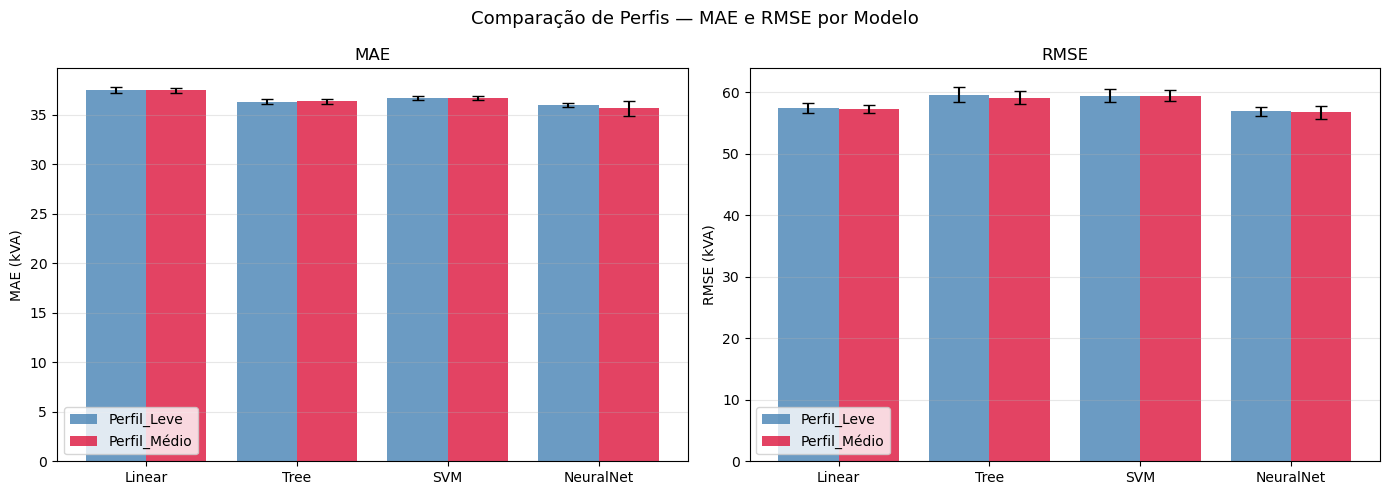

In [14]:
models   = df_cmp['Modelo'].unique()
n_models = len(models)
x        = np.arange(n_models)
width    = 0.8 / len(PROFILES)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comparação de Perfis — MAE e RMSE por Modelo', fontsize=13)

for metric, ax in zip(['MAE', 'RMSE'], axes):
    for i, profile in enumerate(PROFILES):
        color  = colors.get(profile, 'gray')
        subset = df_cmp[df_cmp['Perfil'] == profile].set_index('Modelo')
        vals   = [subset.loc[m, metric]          for m in models]
        stds   = [subset.loc[m, f'{metric}_std'] for m in models]
        ax.bar(x + i * width, vals, width, yerr=stds, label=profile,
            color=color, alpha=0.8, capsize=4)

    ax.set_xticks(x + width * (len(PROFILES) - 1) / 2)
    ax.set_xticklabels(models)
    ax.set_ylabel(f'{metric} (kVA)')
    ax.set_title(metric)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

/tmp/ipykernel_20517/3022432347.py:21: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(lc['train_sizes'], train_mean, 'o-', color=color,
/tmp/ipykernel_20517/3022432347.py:23: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(lc['train_sizes'], val_mean,   'o-', color=color,


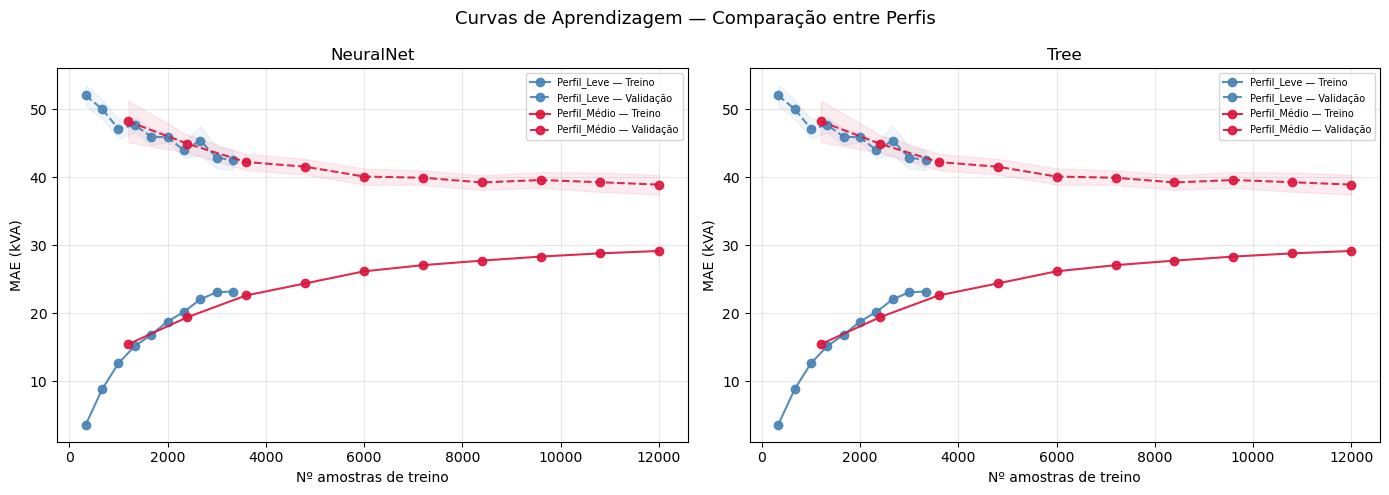

In [20]:
all_models = list(curves_data[PROFILES[0]]['learning_curves'].keys())
fig, axes  = plt.subplots(1, len(all_models), figsize=(7 * len(all_models), 5))
fig.suptitle('Curvas de Aprendizagem — Comparação entre Perfis', fontsize=13)

if len(all_models) == 1:
    axes = [axes]

for ax, model_name in zip(axes, all_models):
    for profile in PROFILES:
        if profile not in curves_data:
            continue
        lc    = curves_data[profile]['learning_curves'].get(model_name)
        if lc is None:
            continue
        color       = colors.get(profile, 'gray')
        train_mean  = lc['train_mae'].mean(axis=1)
        train_std   = lc['train_mae'].std(axis=1)
        val_mean    = lc['val_mae'].mean(axis=1)
        val_std     = lc['val_mae'].std(axis=1)

        ax.plot(lc['train_sizes'], train_mean, 'o-', color=color,
                linestyle='-',  alpha=0.9, label=f'{profile} — Treino')
        ax.plot(lc['train_sizes'], val_mean,   'o-', color=color,
                linestyle='--', alpha=0.9, label=f'{profile} — Validação')
        ax.fill_between(lc['train_sizes'],
                        val_mean - val_std, val_mean + val_std,
                        alpha=0.08, color=color)

    ax.set_title(model_name)
    ax.set_xlabel('Nº amostras de treino')
    ax.set_ylabel('MAE (kVA)')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

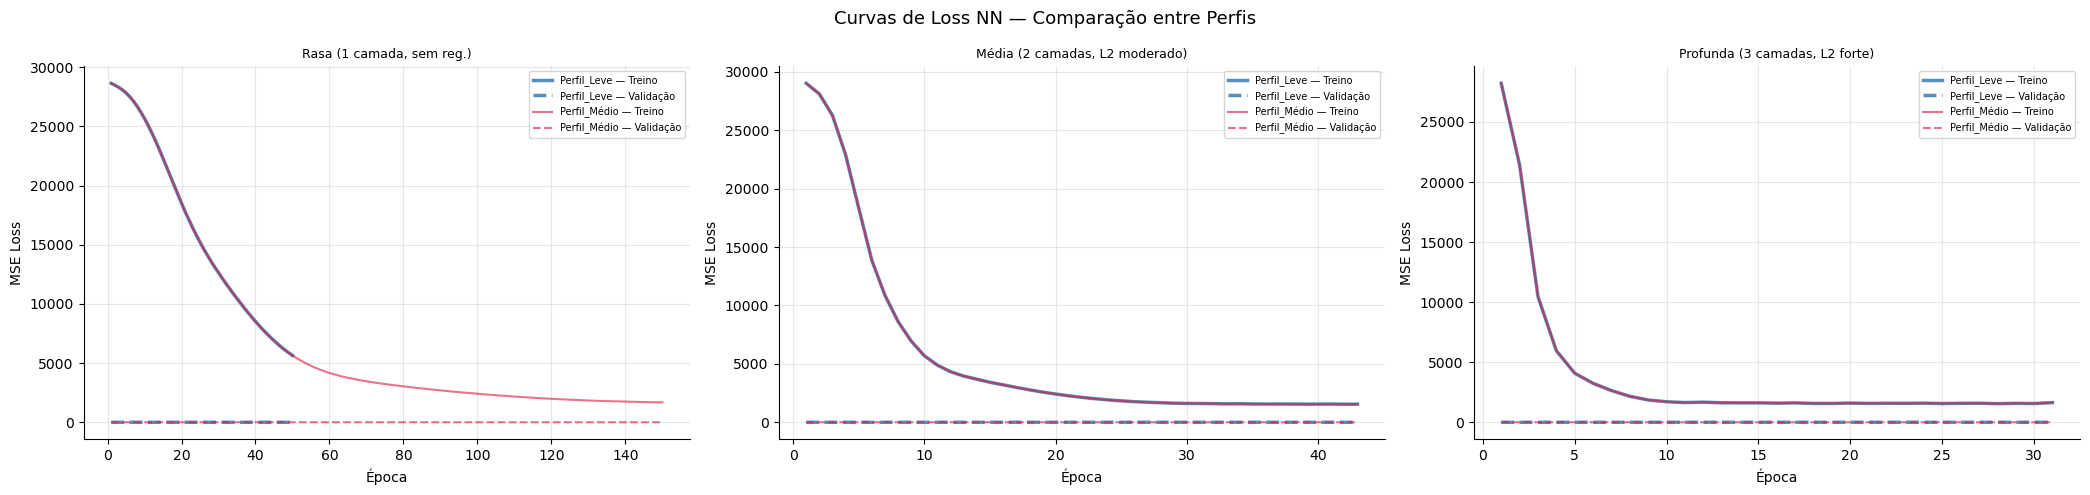

In [25]:
nn_configs_names = [lc['name'] for lc in curves_data[PROFILES[0]]['loss_curves']]

fig, axes = plt.subplots(1, len(nn_configs_names), figsize=(7 * len(nn_configs_names), 5))
fig.suptitle('Curvas de Loss NN — Comparação entre Perfis', fontsize=13)
if len(nn_configs_names) == 1:
    axes = [axes]

for ax, cfg_name in zip(axes, nn_configs_names):
    for profile, style in zip(PROFILES, line_styles):
        if profile not in curves_data:
            continue
        lc = next((l for l in curves_data[profile]['loss_curves'] if l['name'] == cfg_name), None)
        if lc is None:
            continue

        color      = colors.get(profile, 'gray')
        epochs     = range(1, len(lc['train_loss']) + 1)
        val_epochs = range(1, len(lc['val_loss'])   + 1)

        ax.plot(epochs,     lc['train_loss'],
                color=color, linestyle='-',  label=f'{profile} — Treino', **style)
        ax.plot(val_epochs, [-v for v in lc['val_loss']],
                color=color, linestyle='--', label=f'{profile} — Validação', **style)

    ax.set_title(cfg_name, fontsize=9)
    ax.set_xlabel('Época')
    ax.set_ylabel('MSE Loss')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()